In [5]:
import os
import sys

import numpy as np
import pandas as pd
import warnings
import pickle

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

from utility import plot

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier # Added XGBClassifier
from sklearn.ensemble import RandomForestClassifier # Added RandomForestClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [6]:
SEED = 42
PLOT_DPI = 100

TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_fe_train.csv"
# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_smote_fe.csv"
# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_adasyn_fe.csv"
# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_cwgan_fe.csv"
# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_cwgan_reg_ya1_fe.csv"
# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_cwgan_reg_ya1_500_fe.csv"

TEST_DATA_FILE = "../data/preprocessed_skab_dataset_fe_test.csv"

USE_LDA = False
USE_FE = True

In [7]:
dataframe_train = pd.read_csv(TRAIN_DATA_FILE)
# dataframe_train.set_index(pd.to_datetime(dataframe_train.datetime), drop=True, inplace=True)
# dataframe_train.drop(columns=["datetime"], inplace=True)

if not USE_FE:
    og_columns = ["Accelerometer1RMS", "Accelerometer2RMS", "Current", "Pressure", "Temperature", "Thermocouple", "Voltage", "Volume Flow RateRMS", "anomaly", "description"]
    dataframe_train = dataframe_train.drop(columns=[col for col in dataframe_train.columns if col not in og_columns])

dataframe_train.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,description,anomaly
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,76.492320,0.008463,...,59.9847,227.509732,574.313444,0.396142,0.822275,0.000462,0.154822,0.006604,No Anomaly,0.0
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,171.550171,0.042488,...,43.8822,77.025248,299.058927,0.257559,0.670037,0.000036,0.229541,0.005869,No Anomaly,0.0
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,102.209082,0.013628,...,58.5997,366.332439,431.639079,0.848701,0.824648,0.000437,0.204520,0.014483,No Anomaly,0.0
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,77.492989,0.008531,...,57.3947,225.718316,592.311646,0.381080,0.867514,0.000597,0.145544,0.006640,No Anomaly,0.0
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,149.973738,0.009526,...,65.1049,94.131282,310.699174,0.302966,0.631739,0.000137,0.280788,0.004654,No Anomaly,0.0


In [8]:
dataframe_test = pd.read_csv(TEST_DATA_FILE)
# dataframe_test.set_index(pd.to_datetime(dataframe_test.datetime), drop=True, inplace=True)
# dataframe_test.drop(columns=["datetime"], inplace=True)

if not USE_FE:
    og_columns = ["Accelerometer1RMS", "Accelerometer2RMS", "Current", "Pressure", "Temperature", "Thermocouple", "Voltage", "Volume Flow RateRMS", "anomaly", "description"]
    dataframe_test = dataframe_test.drop(columns=[col for col in dataframe_test.columns if col not in og_columns])

dataframe_test.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,description,anomaly
0,0.210323,0.262893,2.65864,1.074847,88.6217,29.3147,230.091,126.677,86.544624,0.008485,...,59.3070,226.931105,519.969766,0.436431,0.800033,0.000436,0.170436,0.007359,No Anomaly,0.0
1,0.028297,0.042536,0.81412,0.745430,68.0318,24.2354,232.174,32.000,285.184002,0.023295,...,43.7964,39.756362,160.664872,0.247449,0.665238,0.000038,0.423439,0.005650,No Anomaly,0.0
2,0.028185,0.041387,0.81061,1.073357,68.8750,24.7075,208.422,32.000,257.117479,0.033542,...,44.1675,57.245837,143.606614,0.398630,0.681015,0.000036,0.479609,0.009025,No Anomaly,0.0
3,0.027955,0.042217,1.12593,1.073357,68.9973,24.7679,235.556,27.000,209.210164,0.039754,...,44.2294,48.301175,225.436632,0.214256,0.662168,0.000044,0.306061,0.004844,Inlet Valve Malfunction,12.0
4,0.211749,0.272061,2.65451,1.402774,90.2739,27.8473,225.678,123.668,85.016820,0.011343,...,62.4266,289.130998,509.204832,0.567809,0.778314,0.000466,0.177284,0.009096,No Anomaly,0.0


In [9]:
scaler = StandardScaler()

values = scaler.fit_transform(dataframe_train.drop(columns=["anomaly", "description"]).values)

if USE_LDA:
    lda = LinearDiscriminantAnalysis()
    values = lda.fit_transform(values, dataframe_train.anomaly.to_numpy().ravel())
    dataframe_train_scaled = pd.DataFrame(values, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, values.shape[1]+1)])
else:
    dataframe_train_scaled = pd.DataFrame(values, columns=dataframe_train.drop(columns=["anomaly", "description"]).columns)

dataframe_train_scaled = dataframe_train_scaled.assign(anomaly=dataframe_train.anomaly.values, description=dataframe_train.description.values)
dataframe_train_scaled

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,0.716365,0.726329,1.652512,-0.090802,1.032226,0.941960,-0.211177,1.140473,-1.070802,-0.213946,...,0.898775,0.935763,1.584489,-0.136463,1.068946,-0.030570,-1.017678,-0.379142,0.0,No Anomaly
1,-0.792652,-0.828083,-0.274864,1.176801,-1.126862,-0.688316,1.478174,-0.923284,-0.100686,0.195903,...,-1.088450,-0.656008,-0.151704,-0.774158,-0.788679,-0.103657,-0.523057,-0.577511,0.0,No Anomaly
2,0.672664,0.674576,0.722498,2.455973,0.964280,1.234189,-0.166682,1.140473,-0.808349,-0.151740,...,0.727851,2.404179,0.684557,1.945997,1.097905,-0.034737,-0.688691,1.748097,0.0,No Anomaly
3,0.998872,0.915484,1.685880,-0.090802,0.743647,0.895296,0.253123,1.118523,-1.060590,-0.213136,...,0.579140,0.916814,1.698015,-0.205770,1.620958,-0.007378,-1.079101,-0.369533,0.0,No Anomaly
4,-0.371240,-0.225833,-0.113309,-1.416344,0.853718,-1.716338,0.414983,0.042958,-0.320885,-0.201148,...,1.530664,-0.475066,-0.078282,-0.565215,-1.255997,-0.086307,-0.183807,-0.905769,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34436,-0.793062,-0.830924,-1.002349,-1.369975,-0.894916,-0.507370,0.369658,-0.923029,0.951005,-0.043732,...,-0.876800,-1.037187,-0.972213,-0.843119,-0.723285,-0.103730,0.732021,-0.725851,0.0,No Anomaly
34437,-0.377952,-0.236648,-0.046487,-0.142957,0.839659,-1.713444,0.057822,0.042532,-0.396003,-0.149806,...,1.513460,-0.030280,-0.044822,0.023694,-1.242862,-0.086828,-0.217775,-0.371197,0.0,No Anomaly
34438,-0.797043,-0.834040,-0.305515,1.176801,-1.076928,-0.664339,0.787804,-0.944806,-0.124560,0.211585,...,-1.038160,-0.680230,-0.240518,-0.752576,-0.782536,-0.103721,-0.437089,-0.563500,0.0,No Anomaly
34439,0.635879,0.695162,1.383122,-0.090802,0.985754,1.190419,0.579975,1.155421,-0.978060,-0.214489,...,0.766540,0.948667,1.449075,-0.055523,0.766921,-0.035927,-0.983103,-0.266101,0.0,No Anomaly


In [10]:
values = scaler.transform(dataframe_test.drop(columns=["anomaly", "description"]).values)

if USE_LDA:
    values = lda.transform(values)
    dataframe_test_scaled = pd.DataFrame(values, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, values.shape[1]+1)])
else:
    dataframe_test_scaled = pd.DataFrame(values, columns=dataframe_test.drop(columns=["anomaly", "description"]).columns)

dataframe_test_scaled = dataframe_test_scaled.assign(anomaly=dataframe_test.anomaly.values, description=dataframe_test.description.values)
dataframe_test_scaled

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,0.643252,0.697546,1.260254,-0.090802,1.000815,1.091693,0.042345,1.133383,-0.968213,-0.213686,...,0.815139,0.929642,1.241711,0.048929,0.797548,-0.034910,-0.914317,-0.175354,0.0,No Anomaly
1,-0.792086,-0.825237,-1.048317,-1.369975,-1.192304,-0.895078,0.234237,-0.944806,1.059007,-0.035294,...,-1.099039,-1.050224,-1.024638,-0.820678,-0.847234,-0.103388,0.760515,-0.636730,0.0,No Anomaly
2,-0.792968,-0.833182,-1.052710,-0.096587,-1.102492,-0.710416,-1.953867,-0.944806,0.772573,0.088146,...,-1.053241,-0.865227,-1.132234,-0.125017,-0.654721,-0.103588,1.132348,0.274598,0.0,No Anomaly
3,-0.794783,-0.827444,-0.658061,-0.096587,-1.089465,-0.686791,0.545797,-1.054557,0.283654,0.162967,...,-1.045602,-0.959841,-0.616084,-0.973416,-0.884690,-0.102342,-0.016508,-0.854283,12.0,Inlet Valve Malfunction
4,0.654496,0.760902,1.255085,1.182585,1.176798,0.517718,-0.364193,1.067334,-0.983805,-0.179258,...,1.200132,1.587570,1.173811,0.653466,0.532539,-0.029872,-0.868986,0.293556,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7376,-0.801370,-0.844196,-0.632967,-0.096587,-1.023618,-0.604141,0.063810,-0.966756,0.199704,0.101179,...,-0.995386,-0.884150,-0.622908,-0.821897,-0.648628,-0.103869,0.011503,-0.667036,12.0,Inlet Valve Malfunction
7377,0.634680,0.686863,1.102254,-0.090802,1.039298,1.036775,-0.619927,1.118523,-0.953155,-0.213136,...,0.877055,0.916814,0.988371,0.205408,0.804545,-0.035338,-0.814887,-0.038511,0.0,No Anomaly
7378,-0.798398,-0.844808,-1.292549,-0.096587,-1.162576,-0.792558,-0.057424,-0.944110,1.924345,0.087746,...,-1.096941,-0.864627,-1.278050,0.229086,-0.514261,-0.103994,1.710510,0.768499,0.0,No Anomaly
7379,0.901544,0.866696,0.837306,1.182585,0.673645,1.158658,1.889227,1.148902,-0.751438,-0.183244,...,0.414942,1.679467,1.074278,0.818043,1.356918,-0.015702,-0.894829,0.744480,0.0,No Anomaly


In [11]:
X_train_scaled = dataframe_train.drop(columns=["anomaly", "description"]).values
y_train = dataframe_train["anomaly"].values.ravel()

X_test_scaled = dataframe_test.drop(columns=["anomaly", "description"]).values
y_test = dataframe_test["anomaly"].values.ravel()

In [12]:
combined = zip(dataframe_train.anomaly.values, dataframe_train.description.values)
sorted_pairs = sorted(combined, key=lambda pair: pair[0])

anomaly_ids = dict()
for i in sorted_pairs:
    anomaly_ids[i[0]] = i[1]

anomaly_names = [val for key, val in anomaly_ids.items()]

In [13]:
def format_cf(cf):
    tp = cf[0, 0]
    fp = np.sum(cf[1:, 0])
    fn = np.sum(cf[0, 1:])
    tn = np.sum(cf[1:, 1:])
    return np.array([[tp, fn], [fp, tn]])

### Logistic Regression

In [14]:
model = LogisticRegression(
                                solver='newton-cholesky', 
                                multi_class='ovr', 
                                C=20) # 'lbfgs' is a good general-purpose solver
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8710


In [15]:
model_data = {
                'model': model,
                'scaler': scaler
}

with open('../models/saved/logistic_regression_og.pickle', 'wb') as handle:
    pickle.dump(model_data, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open('../models/saved/logistic_regression_og.pickle', 'rb') as handle:
    model_data = pickle.load(handle)

model = model_data['model']
scaler = model_data['scaler']

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8710


In [16]:
# plot.make_confusion_matrix(
#     confusion_matrix(y_test, y_pred),
#     categories=anomaly_names,
#     count=False,
#     cbar=False,
#     figsize=(20, 20)
# )

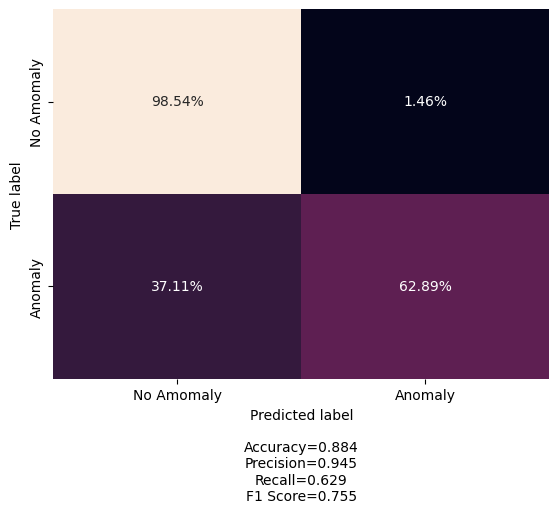

In [17]:
plot.make_confusion_matrix(
    format_cf(confusion_matrix(y_test, y_pred)),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### Random Forest Classifier

In [18]:
model = RandomForestClassifier(n_estimators=100, random_state=SEED)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9610


In [19]:
model_data = {
                'model': model,
                'scaler': scaler
}

with open('../models/saved/random_forest_classifier_og.pickle', 'wb') as handle:
    pickle.dump(model_data, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open('../models/saved/random_forest_classifier_og.pickle', 'rb') as handle:
    model_data = pickle.load(handle)

model = model_data['model']
scaler = model_data['scaler']

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9610


In [20]:
# plot.make_confusion_matrix(
#     confusion_matrix(y_test, y_pred),
#     categories=anomaly_names,
#     count=False,
#     cbar=False,
#     figsize=(20, 20)
# )

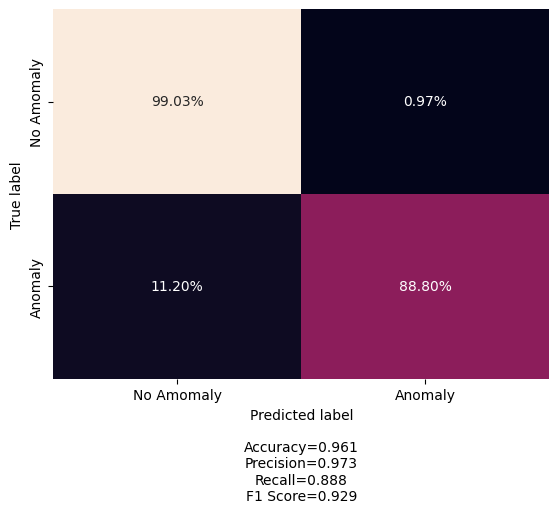

In [21]:
plot.make_confusion_matrix(
    format_cf(confusion_matrix(y_test, y_pred)),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### XGBoost

In [22]:
model = XGBClassifier(objective='multi:softmax', num_class=len(anomaly_names), random_state=SEED)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9665


In [23]:
model_data = {
                'model': model,
                'scaler': scaler
}

with open('../models/saved/xgboost_classifier_og.pickle', 'wb') as handle:
    pickle.dump(model_data, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open('../models/saved/xgboost_classifier_og.pickle', 'rb') as handle:
    model_data = pickle.load(handle)

model = model_data['model']
scaler = model_data['scaler']

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9665


In [24]:
# plot.make_confusion_matrix(
#     confusion_matrix(y_test, y_pred),
#     categories=anomaly_names,
#     count=False,
#     cbar=False,
#     figsize=(20, 20)
# )

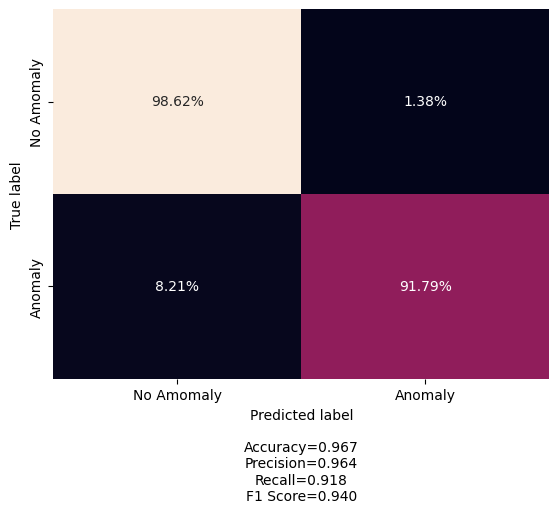

In [25]:
plot.make_confusion_matrix(
    format_cf(confusion_matrix(y_test, y_pred)),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### SVM

In [26]:
# 3. Instantiate and Train SVM
model = SVC(kernel='linear', C=5.0, probability=True) # Example with RBF kernel
model.fit(X_train_scaled, y_train)

# 4. Make Predictions and Evaluate
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9016


In [27]:
model_data = {
                'model': model,
                'scaler': scaler
}

with open('../models/saved/svm_classifier_og.pickle', 'wb') as handle:
    pickle.dump(model_data, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open('../models/saved/svm_classifier_og.pickle', 'rb') as handle:
    model_data = pickle.load(handle)

model = model_data['model']
scaler = model_data['scaler']

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9016


In [28]:
# plot.make_confusion_matrix(
#     confusion_matrix(y_test, y_pred),
#     categories=anomaly_names,
#     count=False,
#     cbar=False,
#     figsize=(20, 20)
# )

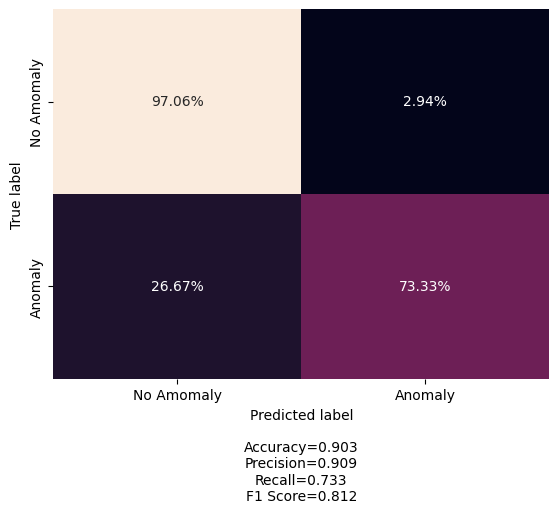

In [29]:
plot.make_confusion_matrix(
    format_cf(confusion_matrix(y_test, y_pred)),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)